# Qualitative features notebook

## Generating test data

In [20]:
import os

# Generate 500 images of size 100x100
!python3 ../samples_generator/samples_generator.py --num_images 2000 --img_size 50
!python3 ../line_detector/line_detector.py --folder_path ../../tests/generated_samples/

# Calculating number of test images
path, dirs, files = next(os.walk("../../tests/generated_samples/"))
file_count = len(files)
print(f"Number of test images: {file_count}")

Traceback (most recent call last):
  File "/Users/mlapin/Development/personal/NaturalAGI/src/training/../samples_generator/samples_generator.py", line 159, in <module>
    generate_triangle_images(args.output_dir, args.num_images, args.img_size, args.is_noised, args.curved_sides,
  File "/Users/mlapin/Development/personal/NaturalAGI/src/training/../samples_generator/samples_generator.py", line 23, in generate_triangle_images
    vertices = generate_triangle(img_size)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/training/../samples_generator/samples_generator.py", line 88, in generate_triangle
    if is_triangle_valid(vertices):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/NaturalAGI/src/samples_generator/image_aggregator.py", line 21, in is_triangle_valid
    calculate_angle(sides[0], sides[2], sides[1]),
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mlapin/Development/personal/N

## Analyze training results

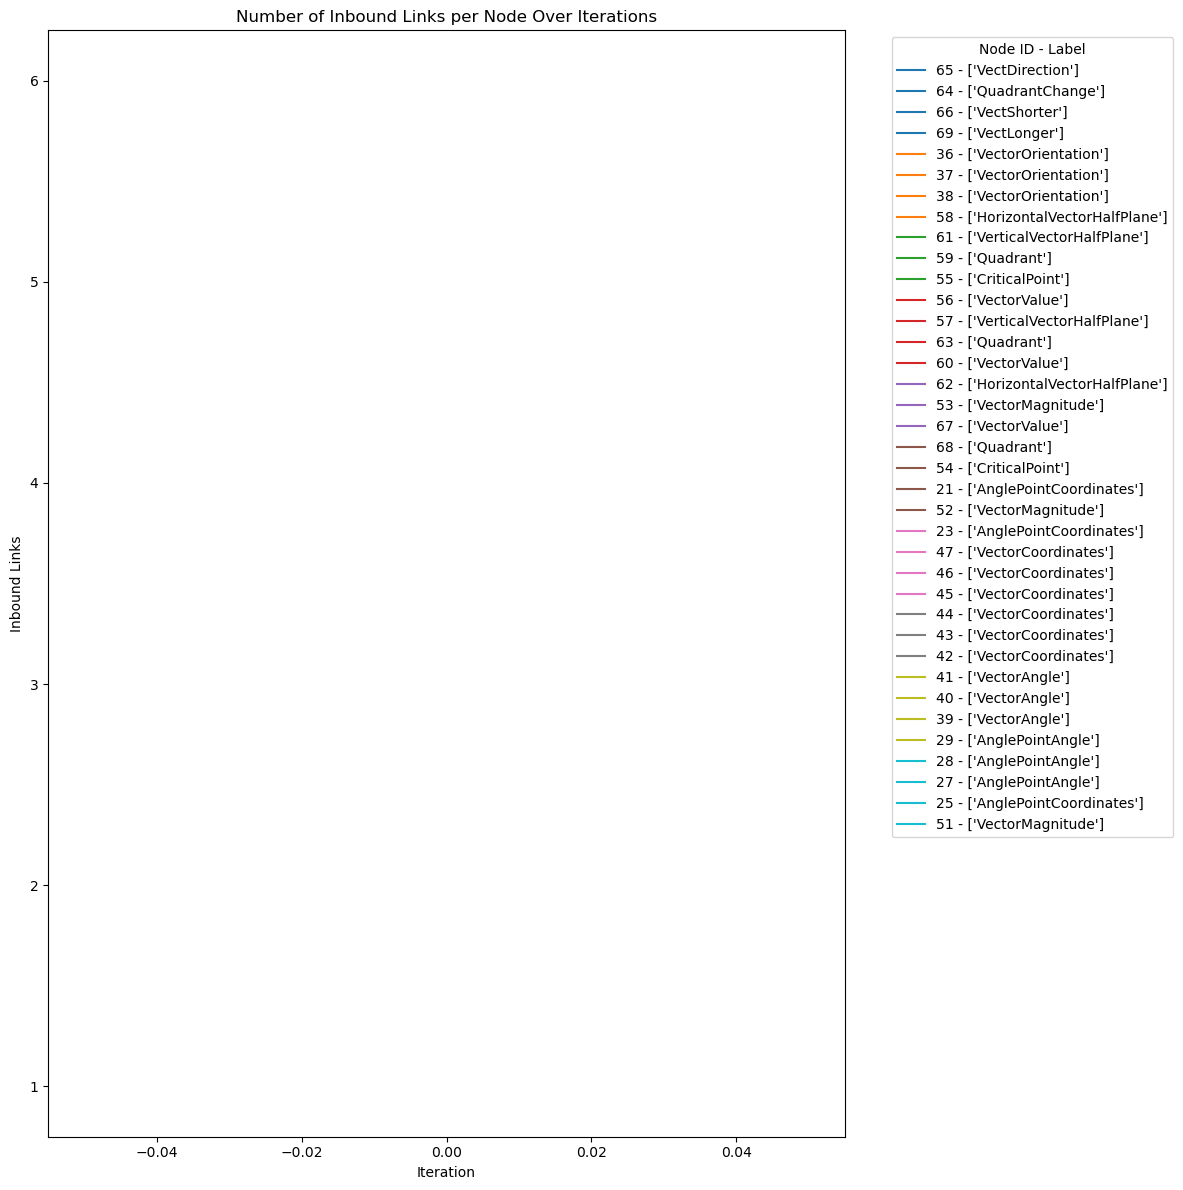

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('../../training_results/qualitative_features.csv')

# Ensure node_id is a string to prevent any unintended type interpretations
df['node_id'] = df['node_id'].astype(str)
df['labels'] = df['labels'].astype(str)  # Ensure labels are treated as string

# Combine 'node_id' and 'labels' for a unique identifier and legend information
df['node_label'] = df['node_id'] + " - " + df['labels']

# Get the latest (or max) relation count for each node_label to order the legend
latest_relation_count = df.groupby('node_label')['relation_count'].max().sort_values(ascending=False)

# Create a sorted list of node_labels based on the latest relation count
sorted_node_labels = latest_relation_count.index.tolist()

# Pivot the DataFrame to have iterations as index and each unique node_label as a column
pivot_df = df.pivot_table(index='iteration', columns='node_label', values='relation_count', aggfunc='max')

# Reorder pivot_df columns based on the sorted node_labels
pivot_df = pivot_df[sorted_node_labels]

# Plotting
fig, ax = plt.subplots(figsize=(12, 12))

# Plot and use the colormap for a wider variety of colors
pivot_df.plot(kind='line', ax=ax, cmap='tab10')

# Title and labels
plt.title('Number of Inbound Links per Node Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Inbound Links')

# Adjust legend - Since we have combined node_id and labels, it will show both
plt.legend(title='Node ID - Label', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to accommodate the legend outside the plot
plt.tight_layout()

# Show the plot
plt.show()